# Ejemplar: Realizar regresión lineal múltiple


## Introducción


Como has aprendido, la regresión lineal múltiple te ayuda a estimar la relación lineal entre una variable dependiente continua y dos o más variables independientes. Para los profesionales de ciencia de datos, esta es una habilidad útil porque te permite comparar más de una variable con la variable que estás midiendo. Esto proporciona la oportunidad para un análisis mucho más exhaustivo y flexible.

Para esta actividad, analizarás los datos históricos de promociones de marketing de un pequeño negocio. Cada fila corresponde a una promoción de marketing independiente donde su negocio utiliza promociones en televisión, redes sociales, radio e influencers para aumentar las ventas. Anteriormente te pidieron encontrar una variable única que predice las ventas, y ahora esperan ampliar este análisis para incluir otras variables que puedan ayudarles a enfocar sus esfuerzos de marketing.

Para abordar la solicitud del negocio, realizarás un análisis de regresión lineal múltiple para estimar las ventas a partir de una combinación de variables independientes. Esto incluirá:

* Explorar y limpiar los datos
* Utilizar gráficos y estadísticas descriptivas para seleccionar las variables independientes
* Crear un modelo de regresión lineal múltiple ajustado
* Verificar las suposiciones del modelo
* Interpretar los resultados del modelo y comunicar los resultados a partes interesadas no técnicas


## Paso 1: Importaciones


### Importar paquetes


Importar bibliotecas y módulos relevantes de Python.


In [1]:
# Import libraries and modules.

### YOUR CODE HERE ### 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

### Cargar conjunto de datos


Cargar el conjunto de datos `marketing_sales_data.csv` como `data` y mostrar las primeras cinco filas. Las variables en el conjunto de datos han sido ajustadas para adaptarse a los objetivos de este laboratorio.


In [14]:
# Load the data.

### YOUR CODE HERE ### 

data = pd.read_csv('marketing_sales_data.csv')

# Display the first five rows.

### YOUR CODE HERE ### 

display(data.head())
print ("el dataset tiene {} filas y {} columnas".format(data.shape[0], data.shape[1]))


,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


el dataset tiene 572 filas y 5 columnas


## Paso 2: Exploración de datos


### Familiarízate con las características de los datos

Comienza con un análisis exploratorio de datos para familiarizarte con los datos y prepararlos para el modelado.

Las características en los datos son:

* Presupuesto promocional en televisión (en categorías "Bajo," "Medio," y "Alto")
* Presupuesto promocional en redes sociales (en millones de dólares)
* Presupuesto promocional en radio (en millones de dólares)
* Ventas (en millones de dólares)
* Tamaño del influencer (en categorías "Mega," "Macro," "Micro," y "Nano")


Pregunta: ¿Cuáles son algunos propósitos del Análisis Exploratorio de Datos (EDA) antes de construir un modelo de regresión lineal múltiple?

Las posibles razones incluyen:

* Entender qué variables están presentes en los datos
* Revisar la distribución de las características, como valores mínimos, medios y máximos
* Graficar la relación entre las variables independientes y dependientes para visualizar qué características tienen una relación lineal
* Identificar problemas con los datos, como valores incorrectos (por ejemplo, errores tipográficos) o valores faltantes


### Crear un par de gráficos de dispersión de los datos

Crear un par de gráficos de dispersión para visualizar la relación entre las variables continuas en `data`.


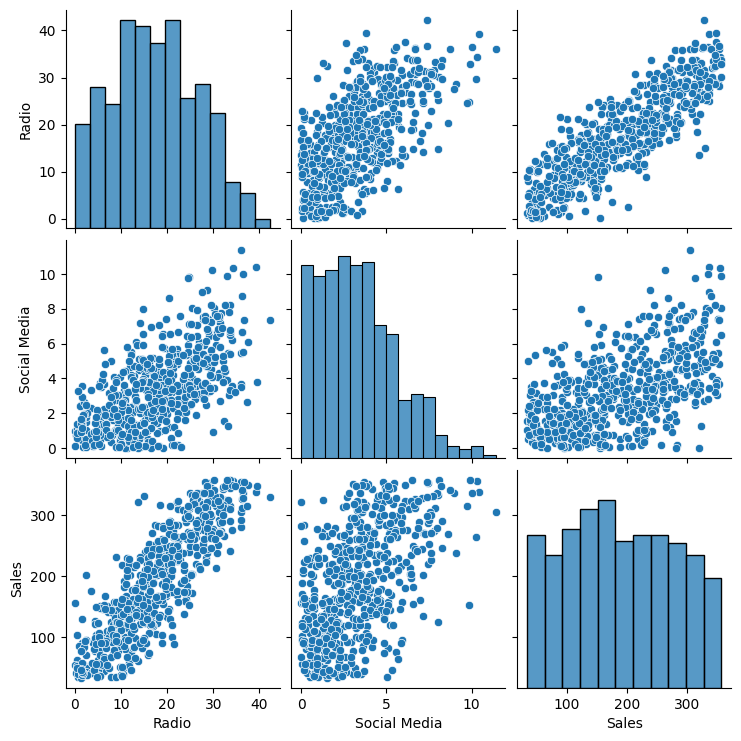

In [ ]:
# Create a pairplot of the data.

### YOUR CODE HERE ### 



<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Consulte [el contenido donde se demuestra cómo crear un par de gráficos](https://www.coursera.org/learn/regression-analysis-simplify-complex-data-relationships/item/dnjWm).

</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

Utiliza la función en la biblioteca `seaborn` que permite crear un pairplot que muestra las relaciones entre variables en los datos.

</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>

Utiliza la función `pairplot()` de la biblioteca `seaborn` y pasa todo el DataFrame.

</details>
<details>
<summary><h6><strong>Codigo</strong></h6></summary>
sns.pairplot(data);


Pregunta: ¿Qué variables tienen una relación lineal con `Sales`? ¿Por qué algunas variables en los datos están excluidas del gráfico anterior?

`Radio` y `Social Media` parecen tener relaciones lineales con `Sales`. Dado esto, `Radio` y `Social Media` pueden ser útiles como variables independientes en un modelo de regresión lineal múltiple que estime `Sales`.

`TV` e `Influencer` están excluidos del pairplot porque no son numéricos.


### Calcular las ventas medias para cada variable categórica


Hay dos variables categóricas: `TV` y `Influencer`. Para caracterizar la relación entre las variables categóricas y `Sales`, encuentra la media de `Sales` para cada categoría en `TV` y la media de `Sales` para cada categoría en `Influencer`.


In [9]:
# Calculate the mean sales for each TV category. 

### YOUR CODE HERE ### 


# Calculate the mean sales for each Influencer category .

### YOUR CODE HERE ### 



<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Encuentra la media `Ventas` cuando la promoción de `TV` es `Alta`, `Media`, o `Baja`.
    
Encuentra la media `Ventas` cuando la promoción de `Influencer` es `Macro`, `Mega`, `Micro`, o `Nano`.  

</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

Utilice la operación `groupby` en `pandas` para dividir un objeto (por ejemplo, datos) en grupos y aplicar un cálculo a cada grupo.

</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>

Para calcular la media `Sales` para cada categoría de `TV`, agrupar por `TV`, seleccionar la columna `Sales`, y luego calcular la media. 
    
Aplica el mismo proceso para calcular la media `Sales` para cada categoría de `Influencer`.

</details>
<details>
<summary><h5><strong>Codigo</strong></h5></summary>

```python
print(data.groupby('TV')['Sales'].mean())

print(data.groupby('Influencer')['Sales'].mean())
```

Pregunta: ¿Qué notas acerca de las variables categóricas? ¿Podrían ser predictores útiles de `Ventas`?

El promedio de `Ventas` para promociones de `TV` `Alta` es considerablemente mayor que para promociones de `TV` `Media` y `Baja`. `TV` puede ser un predictor fuerte de `Ventas`.

Las categorías para `Influencer` tienen diferentes promedios de `Ventas`, pero la variación no es sustancial. `Influencer` puede ser un predictor débil de `Ventas`.

Estos resultados pueden ser investigados más a fondo al ajustar el modelo de regresión lineal múltiple.


### Eliminar datos faltantes

Este conjunto de datos contiene filas con valores faltantes. Para corregir esto, elimine todas las filas que contienen datos faltantes.


In [10]:
# Drop rows that contain missing data and update the DataFrame.

### YOUR CODE HERE ### 

data = data.dropna(axis=0)

In [11]:
data.shape

(572, 5)

<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Utiliza la función `pandas` que elimina valores faltantes.

</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

La función `dropna()` elimina los valores faltantes de un objeto (por ejemplo, DataFrame).

</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>

Utilice `data.dropna(axis=0)` para eliminar todas las filas con valores faltantes en `data`. Asegúrese de actualizar correctamente el DataFrame.

</details>


### Limpiar nombres de columnas


La función `ols()` no se ejecuta cuando los nombres de las variables contienen un espacio. Verifique que los nombres de las columnas en `data` no contengan espacios y corríjalos, si es necesario.


In [18]:
for col in data.columns:

    print(f"{col:15}: {data[col].isnull().sum()} datos faltantes")

TV             : 0 datos faltantes
Radio          : 0 datos faltantes
Social Media   : 0 datos faltantes
Influencer     : 0 datos faltantes
Sales          : 0 datos faltantes


In [19]:
# Rename all columns in data that contain a space. 

### YOUR CODE HERE ### 

data = data.rename(columns={'Social Media': 'Social_Media'})
data.columns

Index(['TV', 'Radio', 'Social_Media', 'Influencer', 'Sales'], dtype='str')

<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Hay un nombre de columna que contiene un espacio. Busca en `data`.

</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

El nombre de la columna `Social Media` en `data` contiene un espacio. Esto no está permitido en la función `ols()`.

</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>

Utilice la función `rename()` en `pandas` y utilice el argumento `columns` para proporcionar un nuevo nombre para `Social Media`.

</details>


## Teoria Sobreajuste y $R^2$: resumen rápido


El coeficiente $R^2$ mide la proporción de la variabilidad de la variable objetivo explicada por el modelo. Al añadir predictores $R^2$ no disminuye, por eso usamos el $R^2$ ajustado para comparar modelos con distinto número de variables:

$$
R^2_{\text{ajustado}} = 1 - \frac{(1-R^2)(n-1)}{n-p-1}
$$

Donde $n$ es el número de observaciones y $p$ el número de predictores. Usa $R^2$ para interpretar cuánto explica el modelo; usa $R^2_{\text{ajustado}}$ para comparar modelos con distinta complejidad.

##  Infraajuste vs Sobreajuste — Sesgo y Varianza



Analogía:
- **Sesgo:** los dardos siempre fallan sistemáticamente del centro (error sistemático).
- **Varianza:** los dardos están muy dispersos entre sí (inestabilidad).
- **Desviación estándar:** raíz cuadrada de la varianza (misma información, otra escala).

Definiciones para un estimador $\hat\theta$:
- $$\mathrm{Bias}(\hat\theta)=\mathbb{E}[\hat\theta]-\theta.$$
- $$\mathrm{Var}(\hat\theta)=\mathbb{E}\big[(\hat\theta-\mathbb{E}[\hat\theta])^2\big].$$
- $$\mathrm{MSE}(\hat\theta)=\mathbb{E}[(\hat\theta-\theta)^2]=\mathrm{Bias}(\hat\theta)^2+\mathrm{Var}(\hat\theta).$$



Aclaración de dominios (para no confundir términos):
- **Sesgo de muestreo**: la muestra no representa la población (problema de muestreo).
- **Sesgo del estimador / modelo**: error sistemático en la inferencia o por asunciones del modelo (underfitting).
- **Varianza del modelo**: sensibilidad del procedimiento a diferentes muestras (overfitting).
Regla práctica: si discutes muestras → sesgo de muestreo; si discutes repeticiones muestrales → bias/variance estadístico; si discutes train vs test → sesgo/varianza en ML.

## Paso 3: Construcción del modelo


### Ajustar un modelo de regresión lineal múltiple que predice ventas

Usando las variables independientes de tu elección, ajusta un modelo de regresión lineal múltiple que predice `Sales` usando dos o más variables independientes de `data`.


In [22]:
# Define the OLS formula.

### YOUR CODE HERE ### 

ols_formula = 'Sales ~ C(TV) + Radio'

# Create an OLS model.

### YOUR CODE HERE ### 

OLS = ols(formula = ols_formula, data = data)

# Fit the model.

### YOUR CODE HERE ### 

model = OLS.fit()

# Save the results summary.

### YOUR CODE HERE ### 

model_results = model.summary()

# Display the model results.

### YOUR CODE HERE ### 

model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1783.
Date:                Fri, 01 May 2026   Prob (F-statistic):          1.63e-288
Time:                        15:40:04   Log-Likelihood:                -2714.0
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5453.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         218.5261      6.261     34.902      0.000     206.228     230.824
C(TV)[T.Low]     -154.2971      4.929    -31.303      0.000    -163.979    -144.616
C(TV)[T.Medium]   -75.3120      3.624    -20.780      0.000     -82.431     -68.193
Radio               2.9669      0.212     14.015      0.000       2.551       3.383
==============================================================================
Omnibus:                       61.244   Durbin-Watson:                   1.870
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.077
Skew:                           0.046   Prob(JB):                     0.000119
Kurtosis:                       2.134   Cond. No.                         142.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Consulte el contenido que discute [construcción de modelos](https://www.coursera.org/learn/regression-analysis-simplify-complex-data-relationships/lecture/zd74V/interpret-multiple-regression-coefficients) para regresión lineal.

</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

Utilice la función `ols()` importada anteriormente—que crea un modelo a partir de una fórmula y un DataFrame—para crear un modelo OLS.

</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>

You previously learned how to specify in `ols()` that a feature is categorical. 
    
Be sure the string names for the independent variables match the column names in `data` exactly.

</details>


Pregunta: ¿Qué variables independientes elegiste para el modelo y por qué?

* `TV` fue seleccionada, ya que el análisis previo mostró una relación fuerte entre el presupuesto promocional de `TV` y las `Ventas` promedio.
* `Radio` fue seleccionada porque el pairplot mostró una relación lineal fuerte entre `Radio` y `Ventas`.
* `Redes Sociales` no fue seleccionada porque no aumentó el rendimiento del modelo y posteriormente se determinó que estaba correlacionada con otra variable independiente: `Radio`.
* `Influencer` no fue seleccionada porque no mostró una relación fuerte con `Ventas` en el análisis previo.


### Verificar supuestos del modelo


Para la regresión lineal múltiple, se añade una suposición adicional a las cuatro suposiciones de la regresión lineal simple: **multicolinealidad**.

Verifique que se cumplan las cinco suposiciones de la regresión lineal múltiple para su modelo.


### Suposición del modelo: linealidad


Crear diagramas de dispersión comparando la(s) variable(s) independiente(s) continua(s) que seleccionaste anteriormente con `Ventas` para verificar la suposición de linealidad. Usa el pairplot que creaste anteriormente para verificar la suposición de linealidad o crea nuevos diagramas de dispersión comparando las variables de interés.


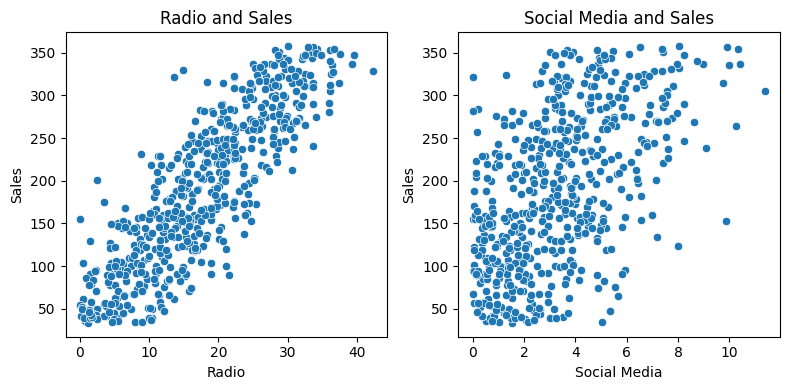

In [23]:
# Create a scatterplot for each independent variable and the dependent variable.

### YOUR CODE HERE ### 

# Create a 1x2 plot figure.
fig, axes = plt.subplots(1, 2, figsize = (8,4))

# Create a scatterplot between Radio and Sales.
sns.scatterplot(x = data['Radio'], y = data['Sales'],ax=axes[0])

# Set the title of the first plot.
axes[0].set_title("Radio and Sales")

# Create a scatterplot between Social Media and Sales.
sns.scatterplot(x = data['Social_Media'], y = data['Sales'],ax=axes[1])

# Set the title of the second plot.
axes[1].set_title("Social Media and Sales")

# Set the xlabel of the second plot.
axes[1].set_xlabel("Social Media")

# Use matplotlib's tight_layout() function to add space between plots for a cleaner appearance.
plt.tight_layout()


<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Utiliza la función en la biblioteca `seaborn` que permite crear un diagrama de dispersión para mostrar los valores de dos variables.

</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

Utilice la función `scatterplot()` en `seaborn`.

</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>
    
Pasa las variables independientes y dependientes en tu modelo como los argumentos para `x` y `y`, respectivamente, en la función `scatterplot()`. Haz esto para cada variable independiente continua en tu modelo.

</details>


**Pregunta:** ¿Se cumple la suposición de linealidad?

La suposición de linealidad se cumple para `Radio`, ya que hay una relación lineal clara en el diagrama de dispersión entre `Radio` y `Ventas`. `Medios Sociales` no fue incluido en el modelo de regresión lineal múltiple anterior, pero parece tener una relación lineal con `Ventas`.


### Suposición del modelo: Independencia


La **suposición de observación independiente** establece que cada observación en el conjunto de datos es independiente. Como cada promoción de marketing (es decir, fila) es independiente de las demás, la suposición de independencia no se viola.


### Suposición del modelo: Normalidad


Crear los siguientes gráficos para verificar la **suposición de normalidad**:

* **Gráfico 1**: Histograma de los residuos
* **Gráfico 2**: Gráfico Q-Q de los residuos


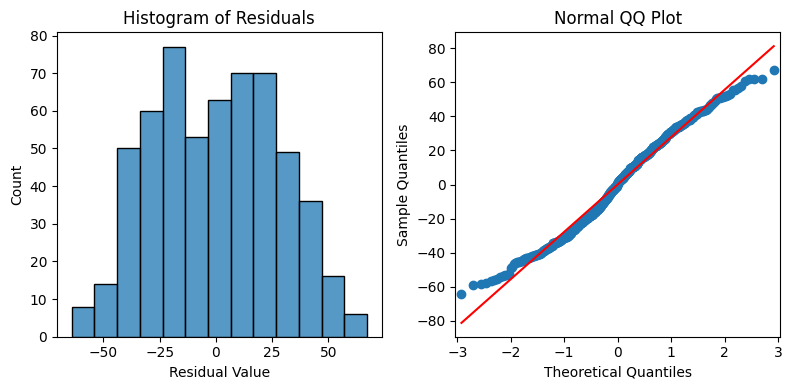

In [24]:
# Calculate the residuals.

### YOUR CODE HERE ### 

residuals = model.resid

# Create a 1x2 plot figure.
fig, axes = plt.subplots(1, 2, figsize = (8,4))

# Create a histogram with the residuals. 

### YOUR CODE HERE ### 

sns.histplot(residuals, ax=axes[0])

# Set the x label of the residual plot.
axes[0].set_xlabel("Residual Value")

# Set the title of the residual plot.
axes[0].set_title("Histogram of Residuals")

# Create a Q-Q plot of the residuals.

### YOUR CODE HERE ### 

sm.qqplot(residuals, line='s',ax = axes[1])

# Set the title of the Q-Q plot.
axes[1].set_title("Normal QQ Plot")

# Use matplotlib's tight_layout() function to add space between plots for a cleaner appearance.
plt.tight_layout()

# Show the plot.
plt.show()

<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Accede a los residuos del objeto del modelo ajustado.

</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

Use `model.resid` para obtener los residuos de un modelo ajustado llamado `model`.

</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>

Para el histograma, pasa los residuos como el primer argumento en la función `seaborn` `histplot()`.
    
Para el gráfico Q-Q, pasa los residuos como el primer argumento en la función `statsmodels` `qqplot()`.

</details>


**Pregunta:** ¿Se cumple la suposición de normalidad?

El histograma de los residuos es aproximadamente normalmente distribuido, lo que respalda que la suposición de normalidad se cumple para este modelo. Los residuos en el gráfico Q-Q forman una línea recta, lo que refuerza que esta suposición se cumple.


### Suposición del modelo: Varianza constante


Verifique que la **suposición de varianza constante** no sea violada creando un diagrama de dispersión con los valores ajustados y los residuos. Agregue una línea en $y = 0$ para visualizar la varianza de los residuos por encima y por debajo de $y = 0$.


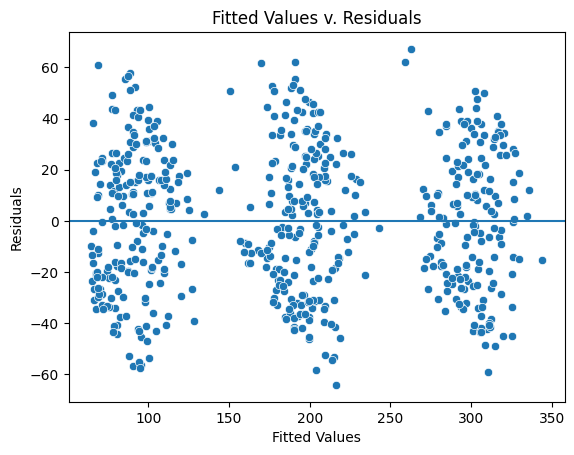

In [25]:
# Create a scatterplot with the fitted values from the model and the residuals.

### YOUR CODE HERE ### 

fig = sns.scatterplot(x = model.fittedvalues, y = model.resid)

# Set the x axis label.
fig.set_xlabel("Fitted Values")

# Set the y axis label.
fig.set_ylabel("Residuals")

# Set the title.
fig.set_title("Fitted Values v. Residuals")

# Add a line at y = 0 to visualize the variance of residuals above and below 0.

### YOUR CODE HERE ### 

fig.axhline(0)

# Show the plot.
plt.show()

<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Accede a los valores ajustados del objeto modelo fit anterior.

</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

Use `model.fittedvalues` para obtener los valores ajustados del modelo ajustado llamado `model`.

</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>

Llamar a la función `scatterplot()` de la biblioteca `seaborn` y pasar los valores ajustados y los residuos.
    
Agregar una línea a una figura usando la función `axline()`.

</details>


**Pregunta 7:** ¿Se cumple la suposición de varianza constante?

Los valores ajustados están en tres grupos porque la variable categórica domina en este modelo, lo que significa que la televisión es el factor más importante que decide las ventas.

Sin embargo, la varianza donde hay valores ajustados está distribuidos de manera similar, validando que se cumple la suposición.


### Suposición del modelo: No multicolinealidad


La **suposición de no multicolinealidad** establece que ninguna dos variables independientes ($X_i$ y $X_j$) pueden estar altamente correlacionadas entre sí.

Dos formas comunes de verificar la multicolinealidad son:

* Crear diagramas de dispersión para mostrar la relación entre pares de variables independientes
* Utilizar el factor de inflación de la varianza para detectar multicolinealidad

Utilice uno de estos dos métodos para verificar la suposición de no multicolinealidad de su modelo.


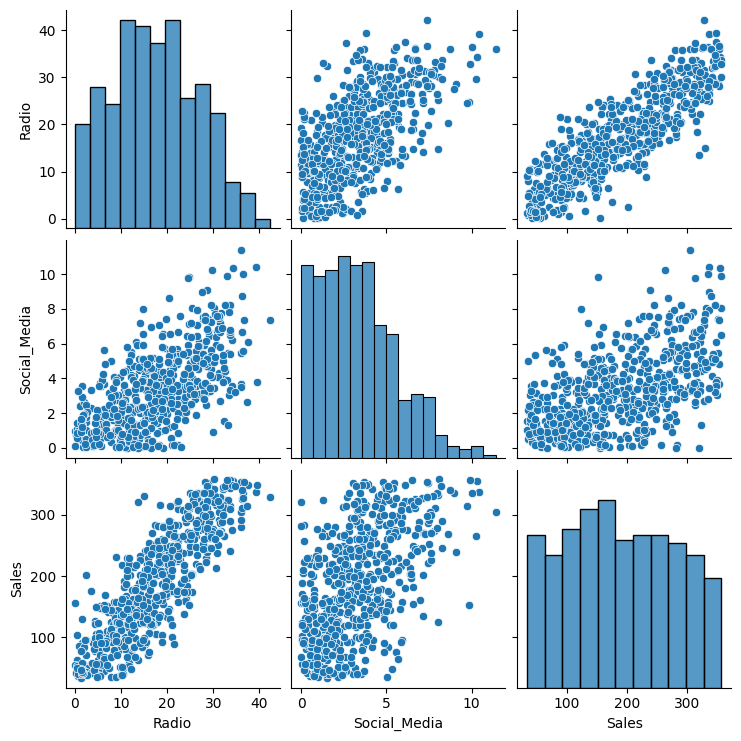

In [26]:
# Create a pairplot of the data.

### YOUR CODE HERE ### 

sns.pairplot(data)

In [27]:
# Calculate the variance inflation factor (optional).

### YOUR CODE HERE ### 

# Import variance_inflation_factor from statsmodels.
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a subset of the data with the continous independent variables. 
X = data[['Radio','Social_Media']]

# Calculate the variance inflation factor for each variable.
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Create a DataFrame with the VIF results for the column names in X.
df_vif = pd.DataFrame(vif, index=X.columns, columns = ['VIF'])

# Display the VIF results.
df_vif

,VIF
Radio,5.170922
Social_Media,5.170922


<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Confirma que previamente creaste gráficos que podrían verificar la suposición de no multicolinealidad.

</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

La función `pairplot()` aplicada anteriormente a `data` traza la relación entre todas las variables continuas (por ejemplo, entre `Radio` y `Social Media`).

</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>

La biblioteca `statsmodels` tiene una función para calcular el factor de inflación de la varianza llamada `variance_inflation_factor()`. 
    
Al usar esta función, selecciona solo los datos que incluyen las variables independientes continuas (por ejemplo, `Radio` y `Social Media`). Consulta tutoriales externos sobre cómo aplicar la función de factor de inflación de la varianza mencionada anteriormente.
 

</details>


Pregunta 8: ¿Se cumple la suposición de no multicolinealidad?

El modelo anterior solo tiene una variable independiente continua, lo que significa que no hay problemas de multicolinealidad.

Si un modelo utilizara tanto `Radio` como `Social_Media` como predictores, habría una relación lineal moderada entre `Radio` y `Social_Media` que viola la suposición de multicolinealidad. Además, el factor de inflación de la varianza cuando se incluyen tanto `Radio` como `Social_Media` en el modelo es 5.17 para cada variable, lo que indica una alta multicolinealidad.


## Selección de variables — pasos básicos


- Objetivo: detectar predictores útiles y evitar sobreajuste.
- Técnicas: Forward Selection, Backward Elimination, Stepwise, Lasso/Ridge.
- Criterios: $R^2_{\text{ajustado}}$, prueba F (suma extra de cuadrados), AIC/BIC, validación cruzada.
- Regla práctica: prioriza variables con sentido teórico; confirma con validación (train/test o cross‑validation).

Celda Código — Mini-experimento bias/variance

In [28]:
# Mini-experimento para ver bias vs varianza en una predicción puntual
import numpy as np

def bias_var_sim(degree=1, n=50, reps=1000, noise=0.3, x0=0.1):
    x = np.linspace(-1,1,n)
    f = lambda x: x**2
    preds = []
    for _ in range(reps):
        y = f(x) + np.random.normal(0,noise,size=n)
        coef = np.polyfit(x,y,deg=degree)
        p = np.poly1d(coef)(x0)
        preds.append(p)
    preds = np.array(preds)
    bias = preds.mean() - f(x0)
    var = preds.var()
    return bias, var

for d in (1,2,9):
    b,v = bias_var_sim(degree=d)
    print(f"degree={d}: bias={b:.4f}, var={v:.4f}")

degree=1: bias=0.3362, var=0.0018
degree=2: bias=-0.0017, var=0.0039
degree=9: bias=-0.0053, var=0.0116


## Paso 4: Resultados y evaluación


### Mostrar los resultados de la regresión OLS

Si se cumplen las suposiciones del modelo, puedes interpretar los resultados del modelo con precisión.

Primero, mostrar los resultados de la regresión OLS.


In [13]:
# Display the model results summary.

### YOUR CODE HERE ### 

model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1783.
Date:                Thu, 18 May 2023   Prob (F-statistic):          1.63e-288
Time:                        21:06:21   Log-Likelihood:                -2714.0
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5453.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         218.5261      6.261     34.902      0.000     206.228     230.824
C(TV)[T.Low]     -154.2971      4.929    -31.303      0.000    -163.979    -144.616
C(TV)[T.Medium]   -75.3120      3.624    -20.780      0.000     -82.431     -68.193
Radio               2.9669      0.212     14.015      0.000       2.551       3.383
==============================================================================
Omnibus:                       61.244   Durbin-Watson:                   1.870
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.077
Skew:                           0.046   Prob(JB):                     0.000119
Kurtosis:                       2.134   Cond. No.                         142.
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Pregunta:** ¿Cuál es tu interpretación del R-cuadrado del modelo?

Usando `TV` y `Radio` como las variables independientes resulta en un modelo de regresión lineal múltiple con $R^{2} = 0.904$. En otras palabras, el modelo explica el $90.4\%$ de la variación en `Ventas`. Esto hace que el modelo sea un excelente predictor de `Ventas`.


### Interpretar coeficientes del modelo


Con la evaluación del ajuste del modelo, puedes observar las estimaciones de los coeficientes y la incertidumbre de estas estimaciones.

Nuevamente, muestra los resultados de la regresión OLS.


In [14]:
# Display the model results summary.

### YOUR CODE HERE ### 

model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1783.
Date:                Thu, 18 May 2023   Prob (F-statistic):          1.63e-288
Time:                        21:06:21   Log-Likelihood:                -2714.0
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5453.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         218.5261      6.261     34.902      0.000     206.228     230.824
C(TV)[T.Low]     -154.2971      4.929    -31.303      0.000    -163.979    -144.616
C(TV)[T.Medium]   -75.3120      3.624    -20.780      0.000     -82.431     -68.193
Radio               2.9669      0.212     14.015      0.000       2.551       3.383
==============================================================================
Omnibus:                       61.244   Durbin-Watson:                   1.870
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.077
Skew:                           0.046   Prob(JB):                     0.000119
Kurtosis:                       2.134   Cond. No.                         142.
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Pregunta:** ¿Cuáles son los coeficientes del modelo?

Cuando `TV` y `Radio` se usan para predecir `Ventas`, los coeficientes del modelo son:

* $\beta_{0} =  218.5261$
* $\beta_{TVLow}= -154.2971$
* $\beta_{TVMedium} = -75.3120$
* $\beta_{Radio} =  2.9669$


Pregunta: ¿Cómo escribirías la relación entre `Ventas` y las variables independientes como una ecuación lineal?


$\text{Ventas} = \beta_{0} + \beta_{1}*X_{1}+ \beta_{2}*X_{2}+ \beta_{3}*X_{3}$

$\text{Ventas} = \beta_{0} + \beta_{TVBajo}*X_{TVBajo}+ \beta_{TVMedio}*X_{TVMedio}+ \beta_{Radio}*X_{Radio}$

$\text{Ventas} = 218.5261 - 154.2971*X_{TVBajo} - 75.3120*X_{TVMedio}+ 2.9669 *X_{Radio}$


Pregunta: ¿Cuál es tu interpretación de las estimaciones de los coeficientes? ¿Son los coeficientes estadísticamente significativos?

La categoría `TV` predeterminada para el modelo es `Alta` ya que hay coeficientes para las otras dos categorías de `TV`, `Media` y `Baja`. Debido a que los coeficientes para las categorías de `TV` `Media` y `Baja` son negativos, eso significa que el promedio de ventas es menor para las categorías de `TV` `Media` o `Baja` en comparación con la categoría de `Alta` de `TV` cuando `Radio` está en el mismo nivel.

Por ejemplo, el modelo predice que una promoción de `Baja` `TV` es 154.2971 menor en promedio en comparación con una promoción de `Alta` `TV` dado la misma promoción de `Radio`.

El coeficiente para `Radio` es positivo, confirmando la relación lineal positiva mostrada anteriormente durante el análisis exploratorio de datos.

El valor p para todos los coeficientes es $0.000$, lo que significa que todos los coeficientes son estadísticamente significativos a $p=0.05$. Los intervalos de confianza del 95% para cada coeficiente deben ser reportados al presentar resultados a las partes interesadas.

Por ejemplo, hay un $95\%$ de probabilidad de que el intervalo $[-163.979,-144.616]$ contenga el parámetro verdadero de la pendiente de $\beta_{TVLow}$, que es la diferencia estimada en ventas de promoción cuando se elige una promoción de `Baja` `TV` en lugar de una promoción de `Alta` `TV`.


**Pregunta:** ¿Por qué es importante interpretar los coeficientes beta?

Los coeficientes beta permiten estimar la magnitud y la dirección (positiva o negativa) del efecto de cada variable independiente sobre la variable dependiente. Las estimaciones de los coeficientes pueden convertirse en conocimientos explicables, como la conexión entre un aumento en los presupuestos promocionales de televisión y las ventas mencionadas anteriormente.


**Pregunta:** ¿En qué estás interesado en explorar según tu modelo?

Áreas potenciales para explorar incluyen:

* Proporcionar a la empresa las ventas estimadas dadas diferentes promociones en TV y presupuestos en radio
* Gráficos adicionales para ayudar a transmitir los resultados, como usar `seaborn` `regplot()` para graficar los datos con una línea de regresión de mejor ajuste


**Pregunta:** ¿Crees que tu modelo podría mejorarse? ¿Por qué o por qué no? ¿Cómo?

Dado lo preciso que fue `TV` como predictor, el modelo podría mejorarse obteniendo una vista más granular de las promociones de `TV`, como considerando más categorías o los presupuestos reales de promoción de `TV`.

Además, variables adicionales, como la ubicación de la campaña de marketing o la época del año, podrían aumentar la precisión del modelo.


## Regularización: introducir sesgo para reducir varianza


- **Lasso (L1):** puede llevar coeficientes a cero → selección automática de variables.  
- **Ridge (L2):** reduce magnitud de coeficientes, no los elimina.  
- **Elastic Net:** combina L1 y L2.  
Usa regularización cuando tienes muchas variables o multicolinealidad; afina el parámetro de penalización por CV.

## Consideraciones

**¿Cuáles son algunas conclusiones clave que aprendiste de este laboratorio?**

* La regresión lineal múltiple es una herramienta poderosa para estimar una variable dependiente continua a partir de varias variables independientes.
* El análisis exploratorio de datos es útil para seleccionar tanto características numéricas como categóricas para la regresión lineal múltiple.
* Ajustar modelos de regresión lineal múltiple puede requerir prueba y error para seleccionar variables que ajusten un modelo preciso mientras se mantienen las suposiciones del modelo.

**¿Qué hallazgos compartirías con otros?**

Según el modelo, los presupuestos promocionales altos en TV resultan en ventas significativamente mayores que los presupuestos promocionales medios y bajos en TV. Por ejemplo, el modelo predice que una promoción de `Baja` en `TV` es 154.2971 menor en promedio que una promoción de `alta` en `TV` dado la misma promoción en `Radio`.

El coeficiente para radio es positivo, confirmando la relación lineal positiva mostrada anteriormente durante el análisis exploratorio de datos.

El valor p para todos los coeficientes es $0.000$, lo que significa que todos los coeficientes son estadísticamente significativos a $p=0.05$. Los intervalos de confianza del 95% para cada coeficiente deben ser reportados al presentar resultados a las partes interesadas.

Por ejemplo, hay un $95\%$ de probabilidad de que el intervalo $[-163.979,-144.616]$ contenga el parámetro verdadero de la pendiente de $\beta_{TVLow}$, que es la diferencia estimada en ventas promocionales cuando se elige un presupuesto promocional bajo en TV en lugar de uno alto en TV.

**¿Cómo enmarcarías tus hallazgos para las partes interesadas?**

Los presupuestos promocionales altos en TV tienen una influencia positiva sustancial en las ventas. El modelo estima que cambiar de un presupuesto alto a uno medio en TV reduce las ventas en $\$75.3120$ millones (IC del 95% $[-82.431,-68.193])$, y cambiar de un presupuesto alto a uno bajo en TV reduce las ventas en $\$154.297$ millones (IC del 95% $[-163.979,-144.616])$. El modelo también estima que un aumento de $\$1$ millón en el presupuesto promocional en radio generará un aumento de $\$2.9669$ millones en ventas (IC del 95% $[2.551,3.383]$).

Por lo tanto, se recomienda que el negocio asigne un presupuesto promocional alto a TV cuando sea posible y que invierta en promociones en radio para aumentar las ventas.


#### **Referencias**

Saragih, H.S. (2020). [*Datos ficticios de marketing y ventas*](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data).


**¡Felicidades!** Has completado este laboratorio. Sin embargo, es posible que no notes una marca de verificación verde junto a este elemento en la plataforma de Coursera. Por favor, continúa con tu progreso independientemente de la marca de verificación. Solo haz clic en el icono de "guardar" en la parte superior de este cuaderno para asegurarte de que tu trabajo haya sido registrado.
